## Домашнее задание
Практика по PyTorch.

### Цель:
Получить навыки практической работы с PyTorch.

### Описание/Пошаговая инструкция выполнения домашнего задания:

#### Используя PyTorch:

1. Создать и обучить регрессионную модель, которая аппроксимирует значение функции sin(x + 2*y)exp(-(2x + y)^2) на диапазоне значений [-10;10] по х и у.
2. В качестве обучающей выборки необходимо сгенерировать 20000 точек случайным образом.
3. Разделить получившийся датасет на train / test / val в отношениях 70% / 15% / 15%, соответственно.

#### Результаты:

1. Посчитать метрику Mean Square Error(MSE) на test.
2. Нарисовать график, в котором сравнивается истинная функция и ее аппроксимированный вариант (предсказываемый моделью).

### Критерии оценки:
- "Принято" - задание выполнено полностью.
- "Возвращено на доработку" - задание не выполнено полностью.

## Решение

In [375]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import random
import os
import math

In [376]:
def seed_everything(seed):
    random.seed(seed) # фиксируем генератор случайных чисел
    os.environ['PYTHONHASHSEED'] = str(seed) # фиксируем заполнения хешей
    np.random.seed(seed) # фиксируем генератор случайных чисел numpy
    torch.manual_seed(seed) # фиксируем генератор случайных чисел pytorch
    torch.cuda.manual_seed(seed) # фиксируем генератор случайных чисел для GPU
    torch.backends.cudnn.deterministic = True # выбираем только детерминированные алгоритмы (для сверток)
    torch.backends.cudnn.benchmark = False # фиксируем алгоритм вычисления сверток

seed_everything(10)

In [377]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

In [397]:
# Для экономии памяти считаю в одинарной вещественной точности
x = np.linspace(-10, 10, 20000) #.astype(np.float32)
X = np.column_stack([x, x])

y = np.sin(X[:, 0] + 2*X[:, 1])*np.exp(-np.pow((2*X[:, 0] + X[:, 1]), 2))

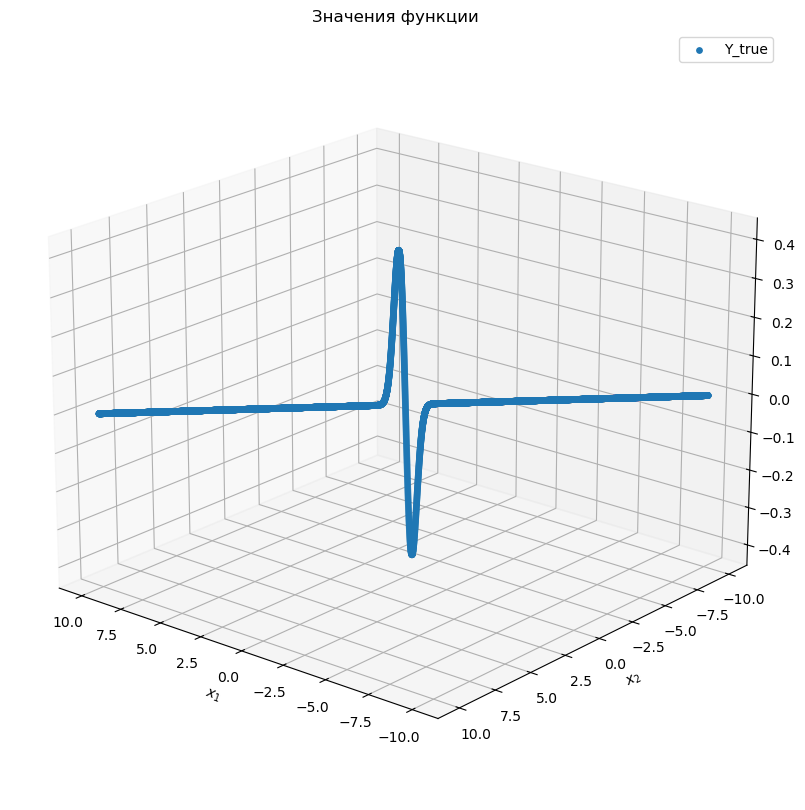

In [404]:
def print_plot(X, y_true, y_pred=None, title=None):
    ax = plt.figure(figsize=(10, 10)).add_subplot(projection='3d')
    
    ax.scatter3D(X[:, 0], X[:, 1], y_true, s=15)
    if (y_pred is not None):
        ax.scatter3D(X[:, 0], X[:, 1], y_pred, s=15)
    ax.view_init(elev=20, azim=130)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel('$y$')
    ax.set_label('123')
    ax.legend(['Y_true', 'Y_pred'])
    if title is not None:
        ax.set_title(title)

print_plot(X=X, y_true=y, title='Значения функции')

In [380]:
# Разбиение исходного множества наблюдений
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=5
)

X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.50, random_state=5
)

print(f'''Размеры наборов:
      Train: {X_train.shape}
      Test: {X_test.shape}
      Val: {X_val.shape}''')

Размеры наборов:
      Train: (14000, 2)
      Test: (3000, 2)
      Val: (3000, 2)


In [381]:
# Конвертация в тензоры PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).view(-1, 1)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val).view(-1, 1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).view(-1, 1)

In [411]:
class Config:
    LEARNING_RATE = 0.001

    INPUT_SIZE = 2
    HIDDEN_SIZE = 100
    OUTPUT_SIZE = 1

In [383]:
# Итератор с батчеризацией
class BatchLoader():
    def __init__(self, X, y, batch_size):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.last_idx = 0
        self.dataset_size = len(X)

    def reset(self):
        self.last_idx = 0

    def __next__(self):
        if (self.last_idx == self.dataset_size):
            raise StopIteration
        
        start_idx = self.last_idx
        end_idx = start_idx + self.batch_size if start_idx + self.batch_size < self.dataset_size else self.dataset_size

        self.last_idx = end_idx
        return self.X[start_idx:end_idx], self.y[start_idx:end_idx]
    
    def __iter__(self):
        return self

    def __len__(self):
        return math.ceil(self.dataset_size / self.batch_size)

In [384]:
# Модель для регрессии функции
class FunctionRegressor(nn.Module):
    def __init__(self, input_size=2, hidden_size=10, output_size=1):
        super(FunctionRegressor, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [412]:
# Проверка архитектуры модели
model = FunctionRegressor(Config.INPUT_SIZE, Config.HIDDEN_SIZE, Config.OUTPUT_SIZE)
model = model.to(device)

batch_check_tensor = X_train[:2].to(device)
print(f'Проверка вывода модели:\n[{model(batch_check_tensor)}]\nдля пакета:\n[{batch_check_tensor}]')
summary(model, (2,))

Проверка вывода модели:
[tensor([[0.3032],
        [0.1658]], device='cuda:0', grad_fn=<AddmmBackward0>)]
для пакета:
[tensor([[-4.2287, -4.2287],
        [-0.8305, -0.8305]], device='cuda:0')]
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 100]             300
              ReLU-2                  [-1, 100]               0
            Linear-3                    [-1, 1]             101
Total params: 401
Trainable params: 401
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [386]:
# Функция для обучения модели
def train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs):
    criterion = nn.MSELoss()

    train_loader = BatchLoader(X_train, y_train, batch_size)
    total_step = len(train_loader)

    # История потерь
    train_losses = []
    val_losses = []
    last_epoch = 0

    for epoch in range(num_epochs):
        need_log_epoch = epoch % (num_epochs // 5) == 0

        if need_log_epoch:
            print(f"Start of {epoch+1} Epoch:")

        train_batch_losses = []
        for i, (X, y) in enumerate(train_loader):  
            model.train()

            # Move tensors to the configured device
            X = X.to(device)
            y = y.to(device)
            
            # Forward pass
            outputs = model(X)
            loss = criterion(outputs, y)

            # Потери по пакету    
            train_batch_losses.append(loss.item())
            
            # Backprpagation and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            need_log_batch = (i % (total_step // 5)) == 0
            if need_log_epoch and need_log_batch:
                print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}' 
                    .format(epoch + 1, num_epochs, i + 1, total_step, loss.item()))

        # Потеря эпохи как средняя потеря по пакету    
        train_losses.append(np.array(train_batch_losses).mean())

        # Расчет потери на валидационной выборке
        val_batch_losses = []
        with torch.no_grad():
            model.eval()
            val_loader = BatchLoader(X_val, y_val, batch_size)
            for (X, y) in val_loader:
                X = X.to(device)
                y = y.to(device)
                outputs = model(X)

                loss = criterion(outputs, y)
                # Потери по пакету    
                val_batch_losses.append(loss.item())
            
            # Потеря эпохи как средняя потеря по пакету   
            val_losses.append(np.array(val_batch_losses).mean())

        val_loader.reset()    
        train_loader.reset()
        last_epoch = epoch

        # Ранняя остановка в случае отсутствия прогресса обучения
        if epoch > num_patience_epochs:
            start_epoch = train_losses[-num_patience_epochs]
            checked_epochs = train_losses[-num_patience_epochs + 1:]
            if all([start_epoch  < checked_epoch for checked_epoch in checked_epochs]):
                break
    
    return (last_epoch + 1, train_losses, val_losses)

In [414]:
# Визуализация потерь на обучающей и валидационной выборке
def print_losses(learning_epochs, train_losses, val_losses, title):
    epochs = range(0, learning_epochs)
    ax = plt.figure(figsize=(10,5))
    plt.title(f'Потери в процессе обучения\n{title}\nЭпохи [{learning_epochs}]')
    plt.plot(epochs, train_losses, label='Train')
    plt.plot(epochs, val_losses, label='Val')
    plt.legend()

In [421]:
# Проверка модели
from sklearn.metrics import mean_squared_error as MSE

def test_model(model, X_test, y_test, bath_size, title):
    test_loader = BatchLoader(X_test, y_test, bath_size)
    y_pred = torch.FloatTensor().to(device)

    with torch.no_grad():
        model.eval()
        for (X, _) in test_loader:
            X = X.to(device)
            outputs = model(X)
        
            y_pred = torch.cat([y_pred, outputs], dim=0)

    y_pred_np = y_pred.cpu().view(-1).numpy()
    y_test_np = y_test.view(-1).numpy()

    score = f'MSE: {MSE(y_true=y_test_np, y_pred=y_pred_np):.6f}'

    print_plot(X_test.numpy(), y_test_np, y_pred_np, title + "\n" + score)

Start of 1 Epoch:
Epoch [1/200], Step [1/55], Loss: 1.4898
Epoch [1/200], Step [12/55], Loss: 0.0264
Epoch [1/200], Step [23/55], Loss: 0.0825
Epoch [1/200], Step [34/55], Loss: 0.0082
Epoch [1/200], Step [45/55], Loss: 0.0151
Start of 41 Epoch:
Epoch [41/200], Step [1/55], Loss: 0.0007
Epoch [41/200], Step [12/55], Loss: 0.0022
Epoch [41/200], Step [23/55], Loss: 0.0020
Epoch [41/200], Step [34/55], Loss: 0.0033
Epoch [41/200], Step [45/55], Loss: 0.0020
Start of 81 Epoch:
Epoch [81/200], Step [1/55], Loss: 0.0003
Epoch [81/200], Step [12/55], Loss: 0.0012
Epoch [81/200], Step [23/55], Loss: 0.0010
Epoch [81/200], Step [34/55], Loss: 0.0016
Epoch [81/200], Step [45/55], Loss: 0.0010
Start of 121 Epoch:
Epoch [121/200], Step [1/55], Loss: 0.0002
Epoch [121/200], Step [12/55], Loss: 0.0008
Epoch [121/200], Step [23/55], Loss: 0.0005
Epoch [121/200], Step [34/55], Loss: 0.0008
Epoch [121/200], Step [45/55], Loss: 0.0006
Start of 161 Epoch:
Epoch [161/200], Step [1/55], Loss: 0.0001
Epoch

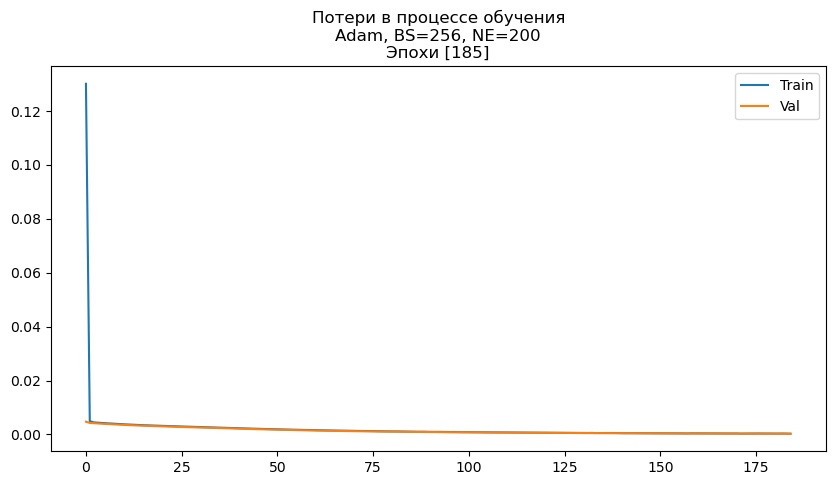

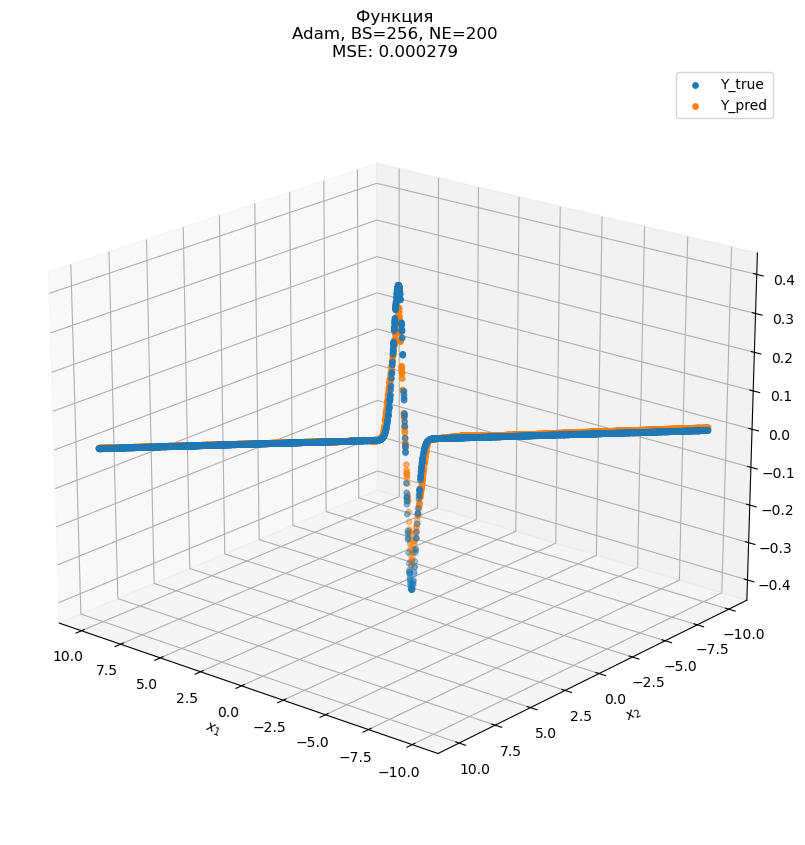

In [422]:
batch_size = 256
num_epochs = 200
num_patience_epochs = 5

model = FunctionRegressor(Config.INPUT_SIZE, Config.HIDDEN_SIZE, Config.OUTPUT_SIZE)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)  

# Обучение
(learning_epochs, train_losses, val_losses) = train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs)

# Проверка и визуализация
model_description = f'Adam, BS={batch_size}, NE={num_epochs}'
print_losses(learning_epochs, train_losses, val_losses, title=model_description)
test_model(model, X_test, y_test, batch_size, title="Функция\n" + model_description)

Start of 1 Epoch:
Epoch [1/200], Step [1/55], Loss: 2.6294
Epoch [1/200], Step [12/55], Loss: 0.0074
Epoch [1/200], Step [23/55], Loss: 0.0065
Epoch [1/200], Step [34/55], Loss: 0.0081
Epoch [1/200], Step [45/55], Loss: 0.0059
Start of 41 Epoch:
Epoch [41/200], Step [1/55], Loss: 0.0010
Epoch [41/200], Step [12/55], Loss: 0.0038
Epoch [41/200], Step [23/55], Loss: 0.0035
Epoch [41/200], Step [34/55], Loss: 0.0056
Epoch [41/200], Step [45/55], Loss: 0.0037
Start of 81 Epoch:
Epoch [81/200], Step [1/55], Loss: 0.0010
Epoch [81/200], Step [12/55], Loss: 0.0035
Epoch [81/200], Step [23/55], Loss: 0.0032
Epoch [81/200], Step [34/55], Loss: 0.0054
Epoch [81/200], Step [45/55], Loss: 0.0034
Start of 121 Epoch:
Epoch [121/200], Step [1/55], Loss: 0.0010
Epoch [121/200], Step [12/55], Loss: 0.0033
Epoch [121/200], Step [23/55], Loss: 0.0030
Epoch [121/200], Step [34/55], Loss: 0.0052
Epoch [121/200], Step [45/55], Loss: 0.0033
Start of 161 Epoch:
Epoch [161/200], Step [1/55], Loss: 0.0010
Epoch

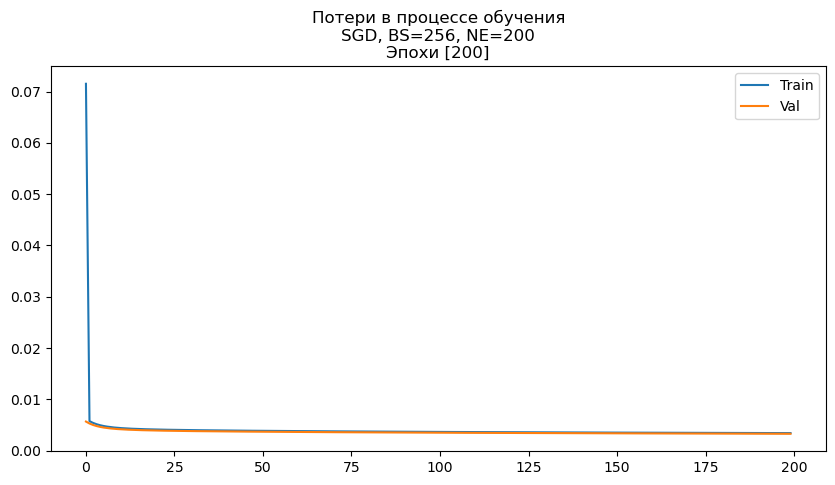

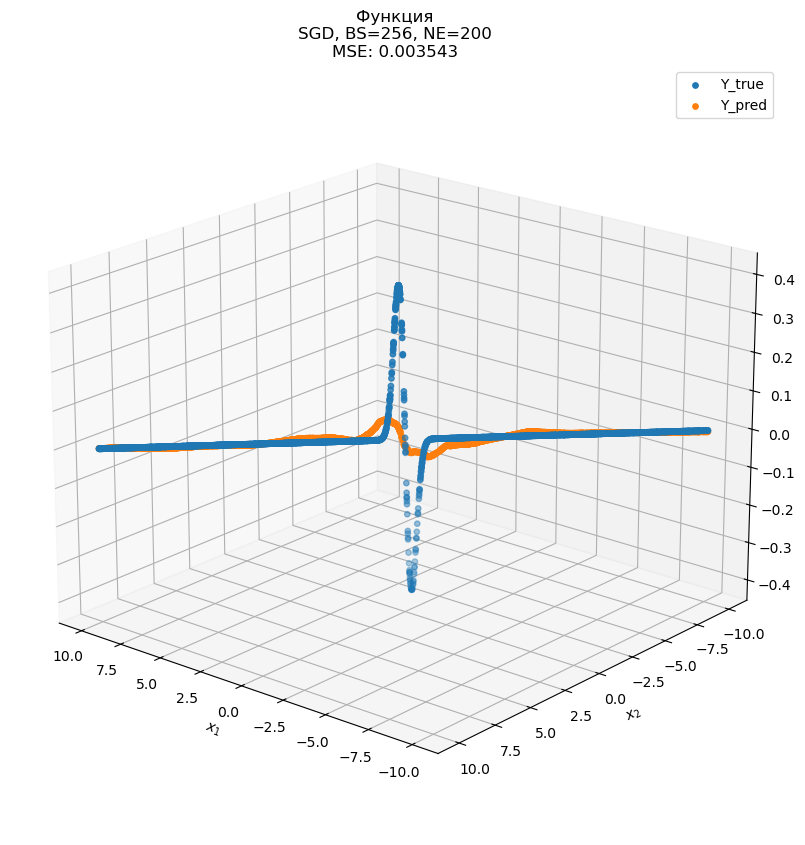

In [423]:
batch_size = 256
num_epochs = 200
num_patience_epochs = 5

model = FunctionRegressor(Config.INPUT_SIZE, Config.HIDDEN_SIZE, Config.OUTPUT_SIZE)
model = model.to(device)
optimizer = optim.SGD(model.parameters(), lr=Config.LEARNING_RATE)  

# Обучение
(learning_epochs, train_losses, val_losses) = train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs)

# Проверка и визуализация
model_description = f'SGD, BS={batch_size}, NE={num_epochs}'
print_losses(learning_epochs, train_losses, val_losses, title=model_description)
test_model(model, X_test, y_test, batch_size, title="Функция\n" + model_description)

Start of 1 Epoch:
Epoch [1/12000], Step [1/55], Loss: 0.2204
Epoch [1/12000], Step [12/55], Loss: 0.0063
Epoch [1/12000], Step [23/55], Loss: 0.0062
Epoch [1/12000], Step [34/55], Loss: 0.0110
Epoch [1/12000], Step [45/55], Loss: 0.0078
Start of 2401 Epoch:
Epoch [2401/12000], Step [1/55], Loss: 0.0005
Epoch [2401/12000], Step [12/55], Loss: 0.0016
Epoch [2401/12000], Step [23/55], Loss: 0.0015
Epoch [2401/12000], Step [34/55], Loss: 0.0023
Epoch [2401/12000], Step [45/55], Loss: 0.0014
Start of 4801 Epoch:
Epoch [4801/12000], Step [1/55], Loss: 0.0003
Epoch [4801/12000], Step [12/55], Loss: 0.0010
Epoch [4801/12000], Step [23/55], Loss: 0.0008
Epoch [4801/12000], Step [34/55], Loss: 0.0011
Epoch [4801/12000], Step [45/55], Loss: 0.0008
Start of 7201 Epoch:
Epoch [7201/12000], Step [1/55], Loss: 0.0002
Epoch [7201/12000], Step [12/55], Loss: 0.0006
Epoch [7201/12000], Step [23/55], Loss: 0.0004
Epoch [7201/12000], Step [34/55], Loss: 0.0006
Epoch [7201/12000], Step [45/55], Loss: 0.000

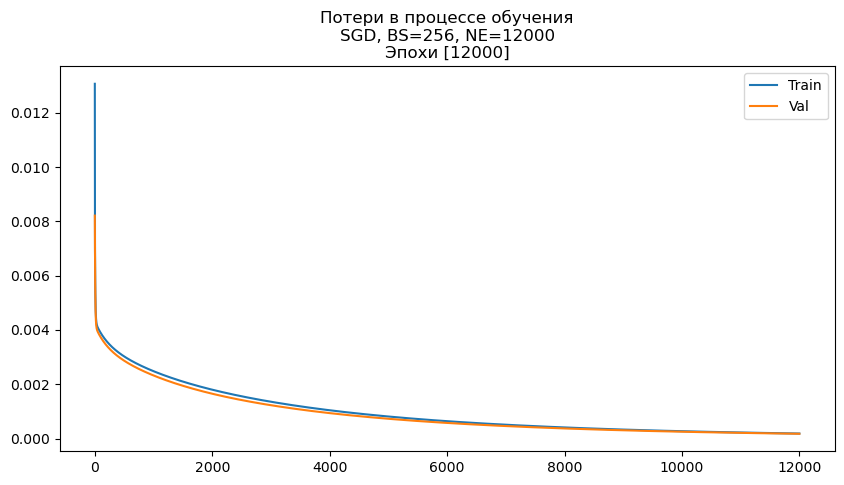

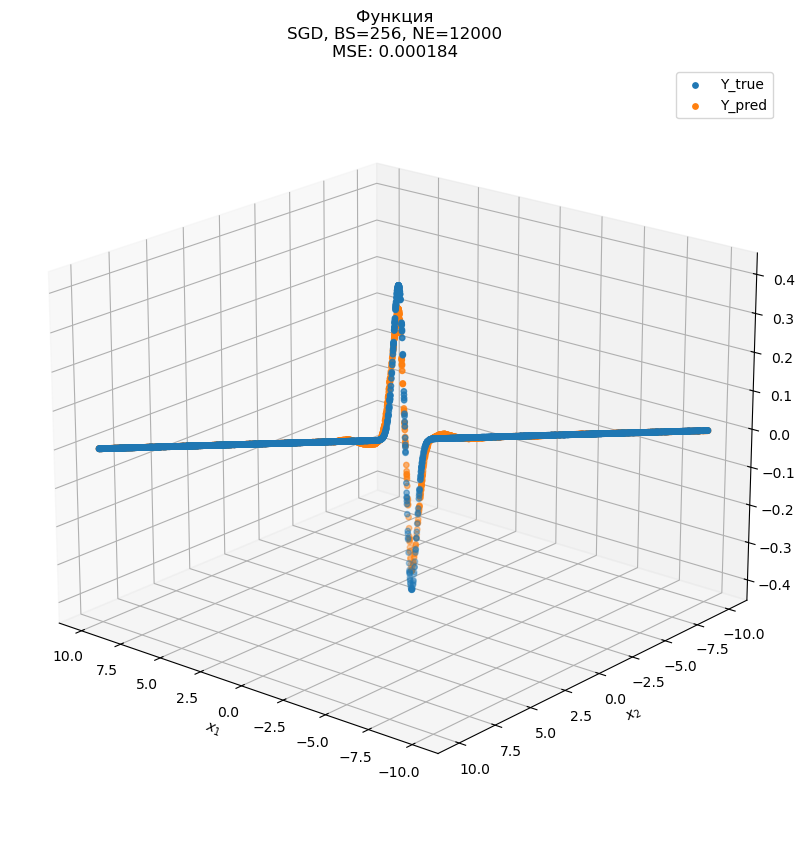

In [ ]:
batch_size = 256
num_epochs = 12000
num_patience_epochs = 5

model = FunctionRegressor(Config.INPUT_SIZE, Config.HIDDEN_SIZE, Config.OUTPUT_SIZE)
model = model.to(device)
optimizer = optim.SGD(model.parameters(), lr=Config.LEARNING_RATE)  

# Обучение
(learning_epochs, train_losses, val_losses) = train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs)

# Проверка и визуализация
model_description = f'SGD, BS={batch_size}, NE={num_epochs}'
print_losses(learning_epochs, train_losses, val_losses, title=model_description)
test_model(model, X_test, y_test, batch_size, title="Функция\n" + model_description)

Start of 1 Epoch:
Epoch [1/5000], Step [1/55], Loss: 1.9751
Epoch [1/5000], Step [12/55], Loss: 0.7492
Epoch [1/5000], Step [23/55], Loss: 0.4168
Epoch [1/5000], Step [34/55], Loss: 0.1997
Epoch [1/5000], Step [45/55], Loss: 0.1070
Start of 1001 Epoch:
Epoch [1001/5000], Step [1/55], Loss: 0.0002
Epoch [1001/5000], Step [12/55], Loss: 0.0009
Epoch [1001/5000], Step [23/55], Loss: 0.0007
Epoch [1001/5000], Step [34/55], Loss: 0.0009
Epoch [1001/5000], Step [45/55], Loss: 0.0006


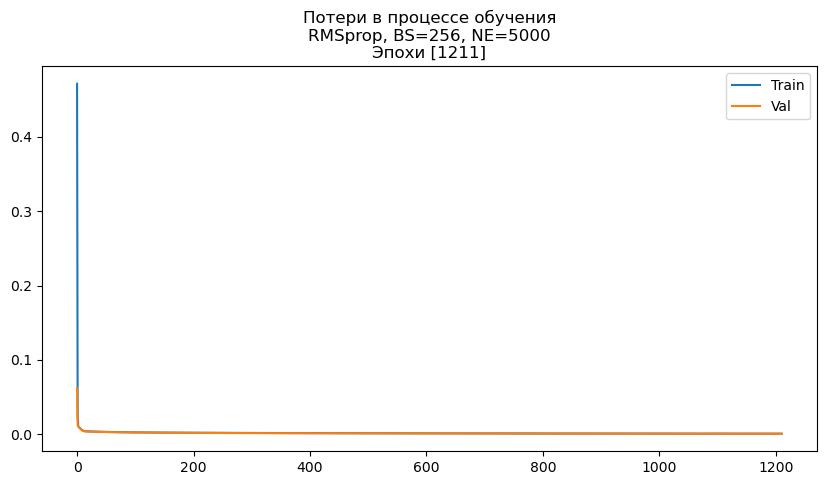

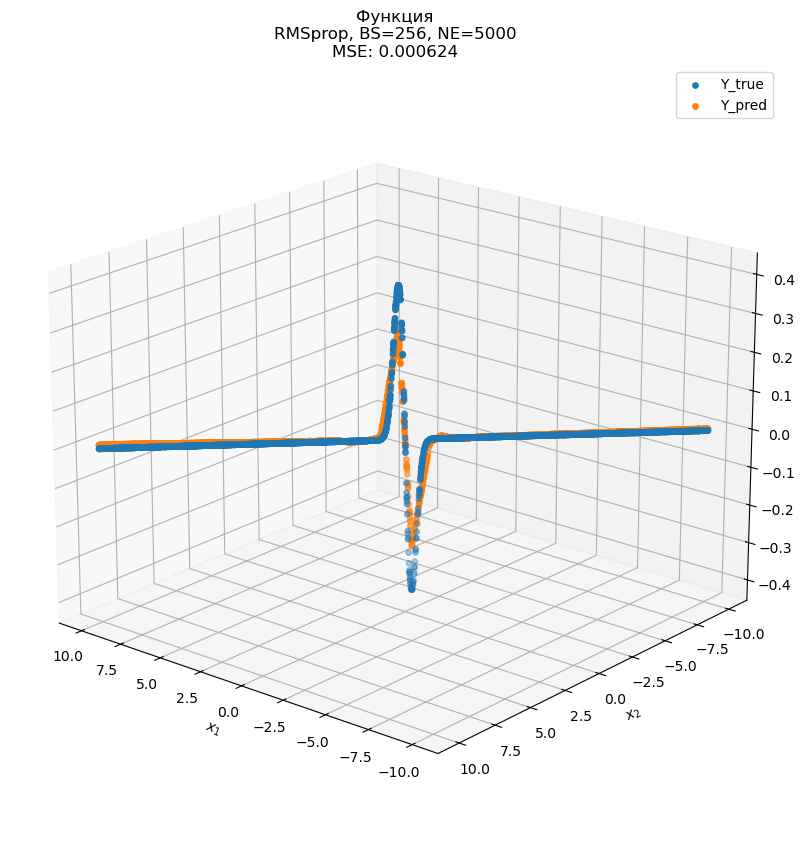

In [450]:
batch_size = 256
num_epochs = 5000
num_patience_epochs = 80
learning_rate = 0.0001

model = FunctionRegressor(Config.INPUT_SIZE, Config.HIDDEN_SIZE, Config.OUTPUT_SIZE)
model = model.to(device)
optimizer = optim.RMSprop(model.parameters(), lr=learning_rate) 

# Обучение
(learning_epochs, train_losses, val_losses) = train_model(model, optimizer, batch_size, num_epochs, num_patience_epochs)

# Проверка и визуализация
model_description = f'RMSprop, BS={batch_size}, NE={num_epochs}'
print_losses(learning_epochs, train_losses, val_losses, title=model_description)
test_model(model, X_test, y_test, batch_size, title="Функция\n" + model_description)

#### Выводы:
1. Наилучшим выбором для данной задачи оказалась работа с оптимизатором Adam - для пакета одного размера в 256 признаков он требует меньшее число эпох, хоть и одна эпоха считается дольше, чем для RMSProp.
2. Наилучшую метрику MSE показал вариант с оптимизатором SGD (0.000184), но он потребовал 12000 эпох и занял в 48 сек. против Adam (0.000279) со 185 эпохами и 8 сек.
3. Обучени RMSProp было не стабильным и порог ранней остановки пришлось увеличить до 80 эпох, против 5 у SGD и Adam.
4. Раннюю остановку не удалось достичь ни при одной комбинации параметров для SGD, это свидетельствует о том, что с каждой эпохой средняя потеря по пакетам не возрастала более 5 эпох подряд.